<a href="https://colab.research.google.com/github/caroccialberto/Python2026/blob/main/project_1_cell_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#in this link you can find the data in drive
#https://drive.google.com/drive/folders/1NOz6iB62hUdgGvZ8_AUjnfP0_xZz86xn?usp=sharing


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
#connect  drive
#from google.colab import drive
#drive.mount('/content/drive')
#import os
#os.chdir('/content/drive/My Drive/python_ex_cells')
#import numpy as np


In [7]:
!ls

counts_pfmca_20200525_cleaned.csv  drive
counts_pfmca_20200525.csv	   sample_data


In [23]:
import pandas as pd
import numpy as np

def open_data(path: str) -> pd.DataFrame:
    """
    Load the counts matrix from CSV.

    Assumptions:
    - First row contains column names (cell IDs)
    - First column contains gene names
    - Rows are genes, columns are cells
    """
    df = pd.read_csv(path, index_col=0)
    return df

def filter_genes_by_cells(df: pd.DataFrame, min_cells: int = 10) -> pd.DataFrame:
    """
    Remove genes expressed in fewer than `min_cells` cells.

    Parameters
    ----------
    df : pd.DataFrame
        Gene x cell count matrix (rows = genes, columns = cells)
    min_cells : int
        Minimum number of cells where gene must have count > 0

    Returns
    -------
    pd.DataFrame
        Filtered dataframe
    """
    gene_counts = (df > 0).sum(axis=1)
    return df.loc[gene_counts >= min_cells,:]
def filter_cells_by_genes(df: pd.DataFrame, min_genes: int = 200) -> pd.DataFrame:
    """
    Remove cells that express fewer than `min_genes` genes.

    Parameters
    ----------
    df : pd.DataFrame
        Gene x cell count matrix
    min_genes : int
        Minimum number of detected genes (count > 0) required for a cell

    Returns
    -------
    pd.DataFrame
        Filtered dataframe
    """
    detected_genes = (df > 0).sum(axis=0)
    return df.loc[:, detected_genes >= min_genes]


def normalize_expression(df: pd.DataFrame, scale_factor: float = 1e4, log: bool = True) -> pd.DataFrame:
    """
    Normalize expression counts by library size (per-cell normalization).

    Steps:
    1. Divide each column by its total counts
    2. Multiply by `scale_factor` (e.g. 1e4)
    3. Optionally apply log1p transformation

    Parameters
    ----------
    df : pd.DataFrame
        Gene x cell count matrix
    scale_factor : float
        Scaling constant after normalization
    log : bool
        Apply log1p transformation if True

    Returns
    -------
    pd.DataFrame
        Normalized expression matrix
    """
    lib_size = df.sum(axis=0)

    normalized = df.div(lib_size, axis=1) * scale_factor

    if log:
        normalized = np.log1p(normalized)

    return normalized



def clean_data(
    df: pd.DataFrame,
    min_exp: int = 10,
    min_cells :int = 10,
    var_threshold: float = 0.5
) -> pd.DataFrame:
    """
    Clean the counts matrix by:
    1. Removing genes present in fewer than `min_exp` cells
       (presence = count > 0)
    2. Removing columns (cells) in the bottom `var_threshold`
       fraction of variance

    Parameters
    ----------
    df : pd.DataFrame
        Gene x cell count matrix
    min_exp : int, default=10
        Minimum number of cells in which a gene must be expressed
    var_threshold : float, default=0.5
        Fraction of lowest-variance columns to remove.
        Example:
        - 0.5 removes the bottom 50% lowest-variance columns
        - 0.2 removes the bottom 20%

    Returns
    -------
    pd.DataFrame
        Cleaned dataset
    """
    if not 0 <= var_threshold < 1:
        raise ValueError("var_threshold must be in the range [0, 1).")

    df = filter_genes_by_cells(df, min_cells)#toglie geni espressi da meno cellule
    df_filtered = filter_cells_by_genes(df, min_exp)# toglie cellule con pochi geni


    # Compute variance for each column (cell)
    col_variances = df_filtered.var(axis=0)

    # Remove columns in the bottom var_threshold fraction
    cutoff = col_variances.quantile(var_threshold)
    df_filtered = df_filtered.loc[:, col_variances > cutoff]

    df_filtered = normalize_expression(df_filtered,log=True)

    return df_filtered


if __name__ == "__main__":
    path = "counts_pfmca_20200525.csv"

    # Load full dataset
    df = open_data(path)

    # Clean dataset
    df_clean = clean_data(df, min_exp=100,min_cells=100, var_threshold=0.4)

    print("Original shape:", df.shape)
    print("Cleaned shape:", df_clean.shape)

    # Optional: save cleaned data
    df_clean.to_csv("counts_pfmca_20200525_cleaned.csv")

Original shape: (5058, 1467)
Cleaned shape: (1344, 563)


In [15]:
(df>0).sum(axis=1)

,0
PF3D7_0100100.1,9
PF3D7_0100300.1,5
PF3D7_0100400.1,3
PF3D7_0100500.1,5
PF3D7_0100600.1,2
...,...
malmito_rna_RNA14:rRNA,51
mal_mito_RNA19:rRNA,34
mal_rna_17:rRNA,1237
mal_rna_18:rRNA,145


In [24]:
df_clean.head()

,X32706_8_5_sorted.bam,X32706_8_7_sorted.bam,X32706_8_8_sorted.bam,X32706_8_13_sorted.bam,X32706_8_15_sorted.bam,X32706_8_19_sorted.bam,X32706_8_20_sorted.bam,X32706_8_24_sorted.bam,X32706_8_25_sorted.bam,X32706_8_27_sorted.bam,...,X31032_1_370_sorted.bam,X31032_1_374_sorted.bam,X31032_1_378_sorted.bam,X31032_1_39_sorted.bam,X31032_1_51_sorted.bam,X31032_1_72_sorted.bam,X31032_1_76_sorted.bam,X31032_1_84_sorted.bam,X31032_1_94_sorted.bam,X31032_1_98_sorted.bam
PF3D7_0103100.1,0.0,0.0,0.00000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,2.640187,2.908526,3.628626,0.000000,3.319036,2.663666,3.373487,3.369761,2.824170,2.616247
PF3D7_0103400.1,0.0,0.0,0.00000,0.0,0.0,0.0,0.060543,0.0,0.0,0.0,...,4.409814,4.523431,3.862972,1.783686,4.763359,3.323457,4.662740,4.508877,4.728586,4.694945
PF3D7_0103600.1,0.0,0.0,0.00000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.000000,0.000000,1.559415,0.000000,0.293506,0.343470,0.419612,0.000000,1.227757,1.384259
PF3D7_0103700.1,0.0,0.0,0.00000,0.0,0.0,0.0,0.405003,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,1.501838,0.000000,0.000000,0.089307,0.000000,0.889373
PF3D7_0103900.1,0.0,0.0,0.09432,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.061579,0.000000


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


def reduce_pca(df: pd.DataFrame, n_components: int = 2) -> pd.DataFrame:
    """
    Apply PCA to the cleaned expression matrix.

    Parameters
    ----------
    df : pd.DataFrame
        Gene x cell expression matrix
    n_components : int
        Number of PCA components

    Returns
    -------
    pd.DataFrame
        DataFrame of shape (cells, n_components)
    """
    # PCA expects samples x features = cells x genes
    X = df.T

    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X)

    cols = [f"PC{i+1}" for i in range(n_components)]
    df_pca = pd.DataFrame(X_pca, index=X.index, columns=cols)

    return df_pca


def plot_pca(df_pca: pd.DataFrame, title: str = "PCA of cells") -> None:
    """
    Plot the first two principal components.
    """
    plt.figure(figsize=(8, 6))
    plt.scatter(df_pca["PC1"], df_pca["PC2"], s=20, alpha=0.7)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def run_pca_visualization(df_clean: pd.DataFrame) -> pd.DataFrame:
    """
    Apply PCA and show a 2D visualization.
    """
    df_pca = reduce_pca(df_clean, n_components=3)
    plot_pca(df_pca, title="PCA visualization of df_clean")
    return df_pca

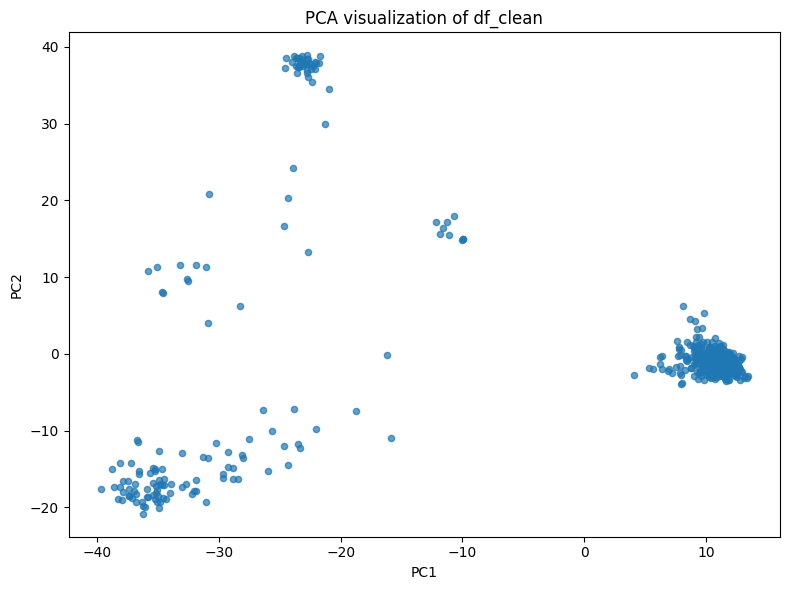

                              PC1       PC2        PC3
X32706_8_5_sorted.bam    9.029416 -1.282686  -3.929961
X32706_8_7_sorted.bam   12.146770 -2.485303  10.432271
X32706_8_8_sorted.bam   10.468972 -1.465714  10.672832
X32706_8_13_sorted.bam   9.143612 -1.492418   8.330301
X32706_8_15_sorted.bam  12.195332 -2.552333  -4.986665


In [29]:
# df_clean is your cleaned and normalized gene x cell matrix
df_pca = run_pca_visualization(df_clean)

print(df_pca.head())

In [30]:
df_pca.shape

(563, 3)

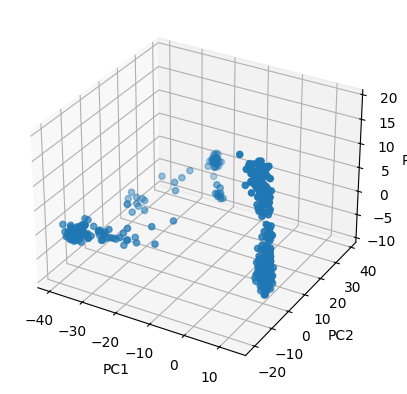

In [41]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

xs = df_pca.PC1
ys = df_pca.PC2
zs = df_pca.PC3

ax.scatter(xs, ys, zs, marker="o")

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')

plt.show()